# Behavioral Results

Within-subject behavioral analysis for the AI advice timing capstone experiment.

## Role of this notebook

This notebook audits the final participant-level behavioral results used in the capstone paper and poster. 

Main responsibilities:

1. **Analysis sample construction** — filter to completed participants and scored trials only
2. **Outcome construction** — compute correctness, asymmetric decision cost, optimal-cost benchmark, and revision variables
3. **Primary inference** — paired tests on per-participant protocol means, matching the within-subject design
4. **Human-first process analysis** — pre/post correction counts and weight of advice (WOA)
5. **Case-level diagnostics** — verify case-level cost variation and difficulty patterns
6. **Notebook-facing outputs** — export compact analysis tables and diagnostic figures directly to `artifacts/tables/` and `artifacts/figures/`

## Scope note

The primary confirmatory outcome is mean trial cost, evaluated with paired $t$-tests on per-participant protocol means. Treating all 1,800 trials as independent would be pseudo-replication because each participant contributes repeated decisions.

Accuracy, human-first correction behavior, WOA, quiz performance, and individual differences are reported as secondary, robustness, or descriptive checks. Table and figure outputs are intentionally compact: only artifacts that support interpretation or reproducibility are saved.

## 1. Setup and constants

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
warnings.filterwarnings("ignore", message=".*covariance.*", module="statsmodels")
warnings.filterwarnings("ignore", message=".*Hessian.*", module="statsmodels")
warnings.filterwarnings("ignore", message=".*singular.*", module="statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import binomtest
import statsmodels.formula.api as smf

try:
    from IPython.display import display
except Exception:
    display = None


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "artifacts").exists() and (candidate / "codes").exists():
            return candidate
    raise RuntimeError("Could not locate repository root. Run from inside the capstone repo.")


ROOT = find_repo_root()
EXPORTS_DIR = ROOT / "data" / "experiment_exports"
TABLES_DIR = ROOT / "artifacts" / "tables"
FIGURES_DIR = ROOT / "artifacts" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TAU = 1 / 6
C_FN = 5
C_FP = 1

PROTOCOLS = ["no_ai", "ai_first", "human_first"]
TIERS = ["easy", "medium", "hard"]
PROTOCOL_LABELS = {
    "no_ai": "No AI",
    "ai_first": "AI-first",
    "human_first": "Human-first",
}

COST_COLOR = "#34445C"
ACCURACY_COLOR = "#0F7F73"
TEXT_COLOR = "#111827"
MUTED_TEXT = "#6B7280"
LIGHT_GRID = "#E5E7EB"
CELL_GRAY = "#DFE3E8"
CELL_GREEN = "#C8F3E8"
CELL_RED = "#F6D6D6"
AXIS_COLOR = "#CBD5E1"
WOA_NO_MOVE_COLOR = "#98A2B3"
WOA_MEDIAN_COLOR = "#C96F32"
TIER_COLORS = {
    "easy": "#5DAE8B",
    "medium": "#E68A4F",
    "hard": "#D96A6A",
}


np.random.seed(42)
pd.set_option("display.max_columns", None)

print("ROOT       :", ROOT)
print("EXPORTS_DIR:", EXPORTS_DIR)
print("TABLES_DIR :", TABLES_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("Working    :", Path.cwd())

ROOT       : /Users/annaasatryan/Desktop/capstone
EXPORTS_DIR: /Users/annaasatryan/Desktop/capstone/data/experiment_exports
TABLES_DIR : /Users/annaasatryan/Desktop/capstone/artifacts/tables
FIGURES_DIR: /Users/annaasatryan/Desktop/capstone/artifacts/figures
Working    : /Users/annaasatryan/Desktop/capstone/codes/notebooks


### Helper functions

In [2]:
def trial_cost(decision: int, y_true: int) -> int:
    """Asymmetric trial cost. decision: 1=approve, 0=reject. y_true: 1=default, 0=paid"""
    if decision == 1 and y_true == 1:
        return C_FN
    if decision == 0 and y_true == 0:
        return C_FP
    return 0


def fmt_p(p: float | None) -> str:
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "p = n/a"
    if p < 0.0001:
        return "p < 0.0001"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def paired_ttest(df: pd.DataFrame, a: str, b: str) -> dict:
    """Paired t-test on per-participant protocol means"""
    if a not in df.columns or b not in df.columns:
        return {"msg": f"columns missing: {a}, {b}"}
    diff = (df[a] - df[b]).dropna()
    n = len(diff)
    if n < 3:
        return {"msg": f"n={n} too small"}
    t_stat, p_val = stats.ttest_1samp(diff, 0)
    mean_diff = float(diff.mean())
    se = float(diff.sem())
    crit = stats.t.ppf(0.975, df=n - 1)
    ci = (mean_diff - crit * se, mean_diff + crit * se)
    sd = float(diff.std(ddof=1))
    cohen_d = mean_diff / sd if sd > 0 else 0.0
    return {
        "n": n,
        "mean_diff": round(mean_diff, 4),
        "ci95": (round(ci[0], 4), round(ci[1], 4)),
        "t": round(float(t_stat), 3),
        "p": float(p_val),
        "d": round(cohen_d, 3),
    }


def ttest_row(pp_df: pd.DataFrame, a: str, b: str) -> dict:
    row = paired_ttest(pp_df, a, b)
    row["label_a"] = PROTOCOL_LABELS[a]
    row["label_b"] = PROTOCOL_LABELS[b]
    if "msg" not in row:
        row["mean_a"] = round(float(pp_df[a].mean()), 4)
        row["mean_b"] = round(float(pp_df[b].mean()), 4)
    return row


def run_contrasts(pp_df: pd.DataFrame) -> list[dict]:
    planned = [
        ("no_ai", "ai_first"),
        ("no_ai", "human_first"),
        ("ai_first", "human_first"),
    ]
    return [ttest_row(pp_df, a, b) for a, b in planned]


def contrast_dataframe(rows: list[dict], metric: str) -> pd.DataFrame:
    out_rows = []
    for row in rows:
        if "msg" in row:
            out_rows.append({"metric": metric, "comparison": f"{row['label_a']} vs {row['label_b']}", "note": row["msg"]})
            continue
        out_rows.append({
            "metric": metric,
            "comparison": f"{row['label_a']} vs {row['label_b']}",
            "mean_a": row["mean_a"],
            "mean_b": row["mean_b"],
            "delta_mean_a_minus_b": row["mean_diff"],
            "ci95_low": row["ci95"][0],
            "ci95_high": row["ci95"][1],
            "t": row["t"],
            "p": row["p"],
            "d": row["d"],
            "n": row["n"],
        })
    return pd.DataFrame(out_rows)


def print_contrast_table(rows: list[dict]) -> None:
    header = f"{'Comparison':<28} {'Mean A':>7} {'Mean B':>7} {'Δ':>8} {'95% CI':>20} {'t':>7} {'p':>12} {'d':>7}"
    print(header)
    print("-" * len(header))
    for row in rows:
        if "msg" in row:
            print(f"  {row['label_a']} vs {row['label_b']}: {row['msg']}")
            continue
        ci_s = f"({row['ci95'][0]:+.3f}, {row['ci95'][1]:+.3f})"
        print(
            f"{row['label_a'] + ' vs ' + row['label_b']:<28} "
            f"{row['mean_a']:>7.4f} {row['mean_b']:>7.4f} {row['mean_diff']:>+8.4f} "
            f"{ci_s:>20} {row['t']:>7.3f} {fmt_p(row['p']):>12} {row['d']:>7.3f}"
        )


def save_fig(fig, filename: str) -> None:
    """Save and display a notebook-facing analysis figure"""
    out = FIGURES_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)

## 2. Load exported experiment data

In [3]:
participants_raw = pd.read_csv(EXPORTS_DIR / "participants.csv")
trials_raw = pd.read_csv(EXPORTS_DIR / "trials.csv")
quiz_raw = pd.read_csv(EXPORTS_DIR / "quiz_responses.csv")

prob_max = trials_raw["prob_estimate_final"].dropna().max()
PROB_SCALE = 100.0 if prob_max > 1.0 else 1.0
if PROB_SCALE == 100.0:
    for col in ("prob_estimate_final", "prob_estimate_init"):
        if col in trials_raw.columns:
            trials_raw[col] = trials_raw[col] / 100.0

print(f"prob scale   : {'0–100 (divided)' if PROB_SCALE == 100 else '0–1 (native)'}")
print(f"participants : {len(participants_raw)}")
print(f"trials       : {len(trials_raw)}")
print(f"quiz rows    : {len(quiz_raw)}")

prob scale   : 0–1 (native)
participants : 158
trials       : 2042
quiz rows    : 411


## 3. Analysis sample

The primary analysis includes only completed participants and scored trials. Practice trials are excluded using `trial_index >= 1`.

In [4]:
comp_mask = participants_raw["completed"].fillna(False).astype(bool)
n_total = len(participants_raw)
n_completed = int(comp_mask.sum())
n_dropped = n_total - n_completed

print(f"Enrolled   : {n_total}")
print(f"Completed  : {n_completed} ({n_completed / n_total:.1%})")
print(f"Dropped    : {n_dropped} ({n_dropped / n_total:.1%})")

group_counts = participants_raw.loc[comp_mask, "participant_group"].value_counts().sort_index()
print("\nGroup balance among completed participants:")
print(group_counts.to_string())
if n_completed >= 3:
    chi2, p_chi = stats.chisquare(group_counts.values)
    print(f"chi2={chi2:.3f} p={p_chi:.3f}")

completed_ids = set(participants_raw.loc[comp_mask, "id"])
scored_a = trials_raw[
    trials_raw["participant_id"].isin(completed_ids) &
    (trials_raw["trial_index"] >= 1)
].copy()
participants_a = participants_raw[participants_raw["id"].isin(completed_ids)].copy()

tpp = scored_a.groupby("participant_id").size()
print(f"\nScored trials : {len(scored_a)} (expected {len(completed_ids) * 18})")
print(f"Trials/person : min={tpp.min()} max={tpp.max()} mean={tpp.mean():.1f}")

assert n_completed == 100, f"Expected 100 completed participants, got {n_completed}"
assert len(scored_a) == 1800, f"Expected 1800 scored trials, got {len(scored_a)}"
assert tpp.min() == 18 and tpp.max() == 18, "Each completed participant should have 18 scored trials"

Enrolled   : 158
Completed  : 100 (63.3%)
Dropped    : 58 (36.7%)

Group balance among completed participants:
participant_group
group_1    30
group_2    36
group_3    34
chi2=0.560 p=0.756

Scored trials : 1800 (expected 1800)
Trials/person : min=18 max=18 mean=18.0


## 4. Derived behavioral variables

In [5]:
scored_a["correct"] = (
    ((scored_a["decision_final"] == 1) & (scored_a["y_true"] == 0)) |
    ((scored_a["decision_final"] == 0) & (scored_a["y_true"] == 1))
).astype(int)

scored_a["trial_cost"] = scored_a.apply(
    lambda r: trial_cost(int(r["decision_final"]), int(r["y_true"])),
    axis=1,
)
scored_a["opt_cost"] = scored_a.apply(
    lambda r: trial_cost(1 if r["pred_prob"] < TAU else 0, int(r["y_true"])),
    axis=1,
)
scored_a["cost_excess"] = scored_a["trial_cost"] - scored_a["opt_cost"]

scored_a["difficulty_tier"] = scored_a["difficulty_tier"].astype(
    pd.CategoricalDtype(TIERS, ordered=True)
)

scored_a["impl_tau"] = (scored_a["prob_estimate_final"] < TAU).astype(int)
scored_a["impl_half"] = (scored_a["prob_estimate_final"] < 0.5).astype(int)
cons_tau = (scored_a["decision_final"] == scored_a["impl_tau"]).mean()
cons_half = (scored_a["decision_final"] == scored_a["impl_half"]).mean()

print("Derived: correct, trial_cost, opt_cost, cost_excess")
print(
    f"prob_estimate range : [{scored_a['prob_estimate_final'].min():.3f}, "
    f"{scored_a['prob_estimate_final'].max():.3f}]"
)
print(f"Decision consistency: tau=0.167 -> {cons_tau:.1%} | tau=0.5 -> {cons_half:.1%}")

Derived: correct, trial_cost, opt_cost, cost_excess
prob_estimate range : [0.000, 0.990]
Decision consistency: tau=0.167 -> 84.6% | tau=0.5 -> 79.1%


## 5. Primary outcome: decision cost

Cost is the primary outcome because the task has asymmetric penalties: approving a defaulter costs 5 units, while rejecting a non-defaulting loan costs 1 unit. The primary inference uses paired tests on per-participant protocol means.

In [6]:
pp_cost = (
    scored_a
    .groupby(["participant_id", "protocol"])["trial_cost"]
    .mean()
    .unstack("protocol")
)

cost_by_proto = (
    scored_a
    .groupby("protocol")[["trial_cost", "opt_cost"]]
    .mean()
    .round(4)
    .reindex(PROTOCOLS)
)

print("Protocol means:")
print(cost_by_proto.to_string())
print(f"AI benchmark (opt_cost overall): {scored_a['opt_cost'].mean():.4f}")

print(f"\n=== PRIMARY INFERENCE: paired t-tests — trial cost (N={len(pp_cost)}) ===")
print_contrast_table(run_contrasts(pp_cost))
print("\nPlanned contrasts. Exact p-values and 95% CIs reported.")
print("AI-first cost reduction is weaker than human-first; interpret accordingly.")

print("\n--- Robustness: trial-level LMM (not primary inference) ---")
_lmm_data = scored_a.dropna(subset=["trial_cost"]).copy()
_lmm_data["block_order_c"] = (
    _lmm_data["block_order"] - _lmm_data["block_order"].mean()
    if "block_order" in _lmm_data.columns else 0
)
try:
    _lmm = smf.mixedlm(
        "trial_cost ~ C(protocol, Treatment('no_ai')) + block_order_c + trial_index",
        _lmm_data,
        groups=_lmm_data["participant_id"],
    ).fit(reml=False)
    if not _lmm.converged:
        print("WARNING: LMM did not converge — do not cite as evidence.")
        print("Paired t-tests are the sole primary inference.")
    else:
        fe = _lmm.fe_params.round(4).to_frame("coef")
        fe["p"] = _lmm.pvalues.round(4)
        fe["CI_low"] = _lmm.conf_int()[0].round(4)
        fe["CI_hi"] = _lmm.conf_int()[1].round(4)
        print(fe.to_string())
except Exception as exc:
    print(f"LMM failed: {exc}")
    print("Paired t-tests are the sole primary inference.")

Protocol means:
             trial_cost  opt_cost
protocol                         
no_ai            1.2217    0.3333
ai_first         1.0117    0.3333
human_first      0.9233    0.3333
AI benchmark (opt_cost overall): 0.3333

=== PRIMARY INFERENCE: paired t-tests — trial cost (N=100) ===
Comparison                    Mean A  Mean B        Δ               95% CI       t            p       d
-------------------------------------------------------------------------------------------------------
No AI vs AI-first             1.2217  1.0117  +0.2100     (+0.038, +0.382)   2.427    p = 0.017   0.243
No AI vs Human-first          1.2217  0.9233  +0.2983     (+0.144, +0.452)   3.846    p < 0.001   0.385
AI-first vs Human-first       1.0117  0.9233  +0.0883     (-0.041, +0.218)   1.356    p = 0.178   0.136

Planned contrasts. Exact p-values and 95% CIs reported.
AI-first cost reduction is weaker than human-first; interpret accordingly.

--- Robustness: trial-level LMM (not primary inference) -

## 6. Secondary outcome: accuracy

In [7]:
pp_acc = (
    scored_a
    .groupby(["participant_id", "protocol"])["correct"]
    .mean()
    .unstack("protocol")
)

print(f"=== SECONDARY INFERENCE: paired t-tests — accuracy (N={len(pp_acc)}) ===")
print_contrast_table(run_contrasts(pp_acc))

print("\n--- Robustness: group_3-excluded sensitivity ---")
_g3 = set(participants_a[participants_a["participant_group"] == "group_3"]["id"])
_eg3 = pp_acc.loc[~pp_acc.index.isin(_g3)]
print(f"Full N={len(pp_acc)} | excl-g3 N={len(_eg3)}")

for a, b in [("no_ai", "ai_first"), ("no_ai", "human_first"), ("ai_first", "human_first")]:
    r_full = paired_ttest(pp_acc, a, b)
    r_excl = paired_ttest(_eg3, a, b)

    def compact_result(row: dict) -> str:
        if row and "msg" not in row:
            return f"t={row['t']} {fmt_p(row['p'])} d={row['d']} n={row['n']}"
        return str(row)

    print(f"  {PROTOCOL_LABELS[a]} vs {PROTOCOL_LABELS[b]}:")
    print(f"    full   : {compact_result(r_full)}")
    print(f"    excl-g3: {compact_result(r_excl)}")

=== SECONDARY INFERENCE: paired t-tests — accuracy (N=100) ===
Comparison                    Mean A  Mean B        Δ               95% CI       t            p       d
-------------------------------------------------------------------------------------------------------
No AI vs AI-first             0.5517  0.6350  -0.0833     (-0.126, -0.041)  -3.921    p < 0.001  -0.392
No AI vs Human-first          0.5517  0.6500  -0.0983     (-0.140, -0.057)  -4.667   p < 0.0001  -0.467
AI-first vs Human-first       0.6350  0.6500  -0.0150     (-0.051, +0.021)  -0.831    p = 0.408  -0.083

--- Robustness: group_3-excluded sensitivity ---
Full N=100 | excl-g3 N=66
  No AI vs AI-first:
    full   : t=-3.921 p < 0.001 d=-0.392 n=100
    excl-g3: t=-4.959 p < 0.0001 d=-0.61 n=66
  No AI vs Human-first:
    full   : t=-4.667 p < 0.0001 d=-0.467 n=100
    excl-g3: t=-5.364 p < 0.0001 d=-0.66 n=66
  AI-first vs Human-first:
    full   : t=-0.831 p = 0.408 d=-0.083 n=100
    excl-g3: t=-0.444 p = 0.658 d=-

## 7. Human-first pre/post correction analysis

Human-first is the only protocol that records an initial decision before AI exposure. This allows direct measurement of whether AI exposure corrected or introduced decision errors.

In [8]:
hf_switch = scored_a[scored_a["protocol"] == "human_first"].dropna(
    subset=["decision_init", "decision_final", "y_true"]
).copy()

hf_switch["correct_init"] = (
    ((hf_switch["decision_init"] == 1) & (hf_switch["y_true"] == 0)) |
    ((hf_switch["decision_init"] == 0) & (hf_switch["y_true"] == 1))
).astype(int)

hf_switch["correct_final"] = (
    ((hf_switch["decision_final"] == 1) & (hf_switch["y_true"] == 0)) |
    ((hf_switch["decision_final"] == 0) & (hf_switch["y_true"] == 1))
).astype(int)

g_stay_ok = int(((hf_switch["correct_init"] == 1) & (hf_switch["correct_final"] == 1)).sum())
g_improved = int(((hf_switch["correct_init"] == 0) & (hf_switch["correct_final"] == 1)).sum())
g_stay_bad = int(((hf_switch["correct_init"] == 0) & (hf_switch["correct_final"] == 0)).sum())
g_worsened = int(((hf_switch["correct_init"] == 1) & (hf_switch["correct_final"] == 0)).sum())
g_n = len(hf_switch)

print(f"N human-first trials: {g_n}")
print(f"  Stayed correct : {g_stay_ok:5d} ({100 * g_stay_ok / g_n:.1f}%)")
print(f"  Improved       : {g_improved:5d} ({100 * g_improved / g_n:.1f}%)")
print(f"  Stayed wrong   : {g_stay_bad:5d} ({100 * g_stay_bad / g_n:.1f}%)")
print(f"  Worsened       : {g_worsened:5d} ({100 * g_worsened / g_n:.1f}%)")
print(f"  Net gain       : {g_improved - g_worsened:+d} ({100 * (g_improved - g_worsened) / g_n:.1f} pp)")

n_changed = g_improved + g_worsened
if n_changed > 0:
    binom_res = binomtest(g_improved, n_changed, 0.5, alternative="greater")
    print(f"\nSign test among changers (n={n_changed}): {g_improved} improved vs {g_worsened} worsened")
    print(f"  One-sided exact binomial {fmt_p(binom_res.pvalue)}")

N human-first trials: 600
  Stayed correct :   300 (50.0%)
  Improved       :    90 (15.0%)
  Stayed wrong   :   178 (29.7%)
  Worsened       :    32 (5.3%)
  Net gain       : +58 (9.7 pp)

Sign test among changers (n=122): 90 improved vs 32 worsened
  One-sided exact binomial p < 0.0001


## 8. Weight of Advice (WOA)

WOA measures movement from the participant's initial probability estimate toward the AI probability in human-first trials:

$$
\mathrm{WOA}_i =
\frac{p^{\mathrm{final}}_i - p^{\mathrm{initial}}_i}
     {p^{\mathrm{AI}}_i - p^{\mathrm{initial}}_i}
$$

The metric is undefined when the initial estimate is already nearly equal to the AI estimate. Trials with denominator magnitude below 0.01 are excluded from WOA summaries.

In [9]:
hf = scored_a[
    (scored_a["protocol"] == "human_first") &
    scored_a["prob_estimate_init"].notna() &
    scored_a["decision_init"].notna()
].copy()

n_hf = len(hf)
print(f"Human-first trials with init+final: {n_hf}")

if n_hf == 0:
    print("No human_first init data — skipping WOA.")
    n_woa_valid = n_no_adj_woa = n_adj_woa = 0
    n_denom_excl = 0
    hf_woa = pd.DataFrame()
    w_all = w_adj = pd.Series(dtype=float)
else:
    hf["prob_moved"] = (hf["prob_estimate_final"] - hf["prob_estimate_init"]).abs()
    hf["denom"] = hf["pred_prob"] - hf["prob_estimate_init"]

    hf_woa = hf[hf["denom"].abs() >= 0.01].copy()
    n_woa_valid = len(hf_woa)
    n_denom_excl = n_hf - n_woa_valid

    hf_woa["woa"] = (
        (hf_woa["prob_estimate_final"] - hf_woa["prob_estimate_init"]) /
        hf_woa["denom"]
    ).clip(-1, 2)

    no_adj_mask_woa = hf_woa["prob_moved"] < 0.01
    n_no_adj_woa = int(no_adj_mask_woa.sum())
    n_adj_woa = n_woa_valid - n_no_adj_woa

    w_all = hf_woa["woa"].dropna()
    w_adj = hf_woa.loc[~no_adj_mask_woa, "woa"].dropna()

    print("\n--- WOA summary ---")
    print(f"  Total human-first trials        : {n_hf}")
    print(f"  Denom-excluded (AI ≈ init_prob) : {n_denom_excl}")
    print(f"  WOA-valid                       : {n_woa_valid}")
    print()
    print(f"Among {n_woa_valid} WOA-valid human-first trials, {n_no_adj_woa} showed")
    print(f"essentially no probability movement ({n_no_adj_woa / n_woa_valid:.1%}).")
    print(f"Among adjusted trials (n={n_adj_woa}), median WOA = {w_adj.median():.3f}.")
    print()
    print(f"WOA distribution (all {len(w_all)} WOA-valid):")
    print(f"  Mean   = {w_all.mean():.3f}")
    print(f"  Median = {w_all.median():.3f}")
    print(f"  SD     = {w_all.std():.3f}")
    print(f"  P25    = {w_all.quantile(.25):.3f}")
    print(f"  P75    = {w_all.quantile(.75):.3f}")
    print(f"\nWOA among adjusters only (n={len(w_adj)}):")
    print(f"  Median = {w_adj.median():.3f}")
    print(f"  Mean   = {w_adj.mean():.3f}")

Human-first trials with init+final: 600

--- WOA summary ---
  Total human-first trials        : 600
  Denom-excluded (AI ≈ init_prob) : 21
  WOA-valid                       : 579

Among 579 WOA-valid human-first trials, 304 showed
essentially no probability movement (52.5%).
Among adjusted trials (n=275), median WOA = 0.869.

WOA distribution (all 579 WOA-valid):
  Mean   = 0.409
  Median = 0.000
  SD     = 0.498
  P25    = 0.000
  P75    = 0.853

WOA among adjusters only (n=275):
  Median = 0.869
  Mean   = 0.861


## 9. Case-level analysis

In [10]:
case_stats = (
    scored_a
    .groupby("case_id", observed=True)
    .agg(
        difficulty_tier=("difficulty_tier", "first"),
        pred_prob=("pred_prob", "first"),
        y_true=("y_true", "first"),
        mean_cost=("trial_cost", "mean"),
        mean_accuracy=("correct", "mean"),
        n_trials=("trial_cost", "size"),
    )
    .reset_index()
    .sort_values("pred_prob")
    .round({"mean_cost": 4, "mean_accuracy": 4, "pred_prob": 4})
)

assert len(case_stats) == 18, f"Expected 18 cases, got {len(case_stats)}"
assert case_stats["n_trials"].eq(100).all(), (
    f"n_trials != 100 for:\n{case_stats[case_stats['n_trials'] != 100]}"
)

print("Case-level cost and accuracy, sorted by AI predicted default probability:")
print(case_stats.to_string(index=False))

print("\nMean by difficulty tier:")
print(
    case_stats
    .groupby("difficulty_tier", observed=True)[["mean_cost", "mean_accuracy", "pred_prob"]]
    .mean()
    .round(4)
    .reindex(TIERS)
    .to_string()
)

rho_case, p_rho_case = stats.spearmanr(case_stats["pred_prob"], case_stats["mean_cost"])
print(f"\nSpearman: pred_prob vs mean_cost rho={rho_case:.3f} {fmt_p(p_rho_case)}")
if p_rho_case >= 0.05:
    print("AI predicted risk alone does not significantly predict mean human trial cost.")
    print("Case-level cost variation reflects difficulty tier and case-specific factors.")
else:
    print("Higher-risk cases cost more on average.")

case_stats.to_csv(TABLES_DIR / "case_level_cost.csv", index=False)
print(f"Saved: {TABLES_DIR / 'case_level_cost.csv'}")

Case-level cost and accuracy, sorted by AI predicted default probability:
 case_id difficulty_tier  pred_prob  y_true  mean_cost  mean_accuracy  n_trials
 1183988            easy     0.0547       0       0.22           0.78       100
  828575            easy     0.0750       0       0.17           0.83       100
 1100864            easy     0.1016       0       0.23           0.77       100
  819289          medium     0.1686       0       0.07           0.93       100
 1121112          medium     0.1888       0       0.14           0.86       100
  819343          medium     0.2100       0       0.30           0.70       100
  819669          medium     0.2343       1       3.80           0.24       100
 1185020          medium     0.2671       1       1.80           0.64       100
  835430          medium     0.2959       1       3.95           0.21       100
  844888            easy     0.3333       1       1.70           0.66       100
  937917            easy     0.3704       1   

## 10. Final reported result checks

In [11]:
print("=" * 72)
print("FINAL REPORTED RESULTS — COMPUTED CHECKS")
print("=" * 72)

cost_means = cost_by_proto["trial_cost"].to_dict()
acc_means = pp_acc.mean().round(4).to_dict()

r_cost_ai = paired_ttest(pp_cost, "no_ai", "ai_first")
r_cost_hf = paired_ttest(pp_cost, "no_ai", "human_first")
r_cost_timing = paired_ttest(pp_cost, "ai_first", "human_first")
r_acc_ai = paired_ttest(pp_acc, "no_ai", "ai_first")
r_acc_hf = paired_ttest(pp_acc, "no_ai", "human_first")
r_acc_timing = paired_ttest(pp_acc, "ai_first", "human_first")

# Hard consistency checks for paper-reported values
assert len(completed_ids) == 100
assert len(scored_a) == 1800
assert np.isclose(cost_means["no_ai"], 1.2217, atol=0.0001)
assert np.isclose(cost_means["ai_first"], 1.0117, atol=0.0001)
assert np.isclose(cost_means["human_first"], 0.9233, atol=0.0001)
assert np.isclose(acc_means["no_ai"], 0.5517, atol=0.0001)
assert np.isclose(acc_means["ai_first"], 0.6350, atol=0.0001)
assert np.isclose(acc_means["human_first"], 0.6500, atol=0.0001)
assert (g_stay_ok, g_worsened, g_improved, g_stay_bad) == (300, 32, 90, 178)
assert (n_hf, n_woa_valid, n_no_adj_woa, n_adj_woa) == (600, 579, 304, 275)
assert np.isclose(float(w_adj.median()), 0.869, atol=0.001)


def claim(num: int, text: str) -> None:
    print(f"\nClaim {num}: {text}")

claim(1, "AI-supported protocols reduced decision cost relative to no AI")
print(
    f"  No AI={cost_means.get('no_ai', float('nan')):.4f}  "
    f"AI-first={cost_means.get('ai_first', float('nan')):.4f}  "
    f"Human-first={cost_means.get('human_first', float('nan')):.4f}"
)
print(f"  No AI vs AI-first   : Δ={r_cost_ai['mean_diff']:+.4f} {fmt_p(r_cost_ai['p'])} d={r_cost_ai['d']}")
print(f"  No AI vs Human-first: Δ={r_cost_hf['mean_diff']:+.4f} {fmt_p(r_cost_hf['p'])} d={r_cost_hf['d']}")

claim(2, "Human-first was best descriptively, but not statistically decisive versus AI-first")
print(f"  AI-first vs Human-first: Δ={r_cost_timing['mean_diff']:+.4f} {fmt_p(r_cost_timing['p'])} d={r_cost_timing['d']}")

claim(3, "Accuracy follows the same ordering as cost")
print(f"  No AI={acc_means['no_ai']:.4f}  AI-first={acc_means['ai_first']:.4f}  Human-first={acc_means['human_first']:.4f}")
print(f"  No AI vs AI-first   : Δ={r_acc_ai['mean_diff']:+.4f} {fmt_p(r_acc_ai['p'])} d={r_acc_ai['d']}")
print(f"  No AI vs Human-first: Δ={r_acc_hf['mean_diff']:+.4f} {fmt_p(r_acc_hf['p'])} d={r_acc_hf['d']}")
print(f"  AI-first vs Human-first: Δ={r_acc_timing['mean_diff']:+.4f} {fmt_p(r_acc_timing['p'])} d={r_acc_timing['d']}")

claim(4, "Human-first AI exposure corrected more initial errors than it introduced")
print(f"  Improved={g_improved} Worsened={g_worsened} Net={g_improved - g_worsened:+d} p < 0.0001 one-sided")

claim(5, "Reliance was heterogeneous")
print(f"  {n_woa_valid} WOA-valid trials: {n_no_adj_woa} no-adjustment ({n_no_adj_woa / n_woa_valid:.1%})")
print(f"  Median WOA among adjusted trials (n={n_adj_woa}) = {w_adj.median():.3f}")

claim(6, "Case-level cost was not monotonically ordered by AI risk in the selected case set")
print(f"  Spearman rho={rho_case:.3f} {fmt_p(p_rho_case)}")

print("\nInterpretation boundary:")
print("  AI support improved outcomes relative to no AI")
print("  The direct timing contrast between AI-first and human-first is not statistically decisive at the achieved sample size")

FINAL REPORTED RESULTS — COMPUTED CHECKS

Claim 1: AI-supported protocols reduced decision cost relative to no AI
  No AI=1.2217  AI-first=1.0117  Human-first=0.9233
  No AI vs AI-first   : Δ=+0.2100 p = 0.017 d=0.243
  No AI vs Human-first: Δ=+0.2983 p < 0.001 d=0.385

Claim 2: Human-first was best descriptively, but not statistically decisive versus AI-first
  AI-first vs Human-first: Δ=+0.0883 p = 0.178 d=0.136

Claim 3: Accuracy follows the same ordering as cost
  No AI=0.5517  AI-first=0.6350  Human-first=0.6500
  No AI vs AI-first   : Δ=-0.0833 p < 0.001 d=-0.392
  No AI vs Human-first: Δ=-0.0983 p < 0.0001 d=-0.467
  AI-first vs Human-first: Δ=-0.0150 p = 0.408 d=-0.083

Claim 4: Human-first AI exposure corrected more initial errors than it introduced
  Improved=90 Worsened=32 Net=+58 p < 0.0001 one-sided

Claim 5: Reliance was heterogeneous
  579 WOA-valid trials: 304 no-adjustment (52.5%)
  Median WOA among adjusted trials (n=275) = 0.869

Claim 6: Case-level cost was not mono

## 11. Export compact analysis tables

Only compact tables needed for traceability are written. Participant-level wide tables are not exported by default because they duplicate the raw database exports and create unnecessary artifacts.

In [12]:
protocol_outcomes = pd.DataFrame({
    "protocol": PROTOCOLS,
    "label": [PROTOCOL_LABELS[p] for p in PROTOCOLS],
    "mean_trial_cost": [float(pp_cost[p].mean()) for p in PROTOCOLS],
    "mean_accuracy": [float(pp_acc[p].mean()) for p in PROTOCOLS],
    "mean_optimal_cost": [float(cost_by_proto.loc[p, "opt_cost"]) for p in PROTOCOLS],
    "n_participants": [int(pp_cost[p].notna().sum()) for p in PROTOCOLS],
    "n_trials": [int((scored_a["protocol"] == p).sum()) for p in PROTOCOLS],
})
protocol_outcomes.to_csv(TABLES_DIR / "protocol_outcomes.csv", index=False)

protocol_contrasts = pd.concat(
    [
        contrast_dataframe(run_contrasts(pp_cost), "trial_cost"),
        contrast_dataframe(run_contrasts(pp_acc), "accuracy"),
    ],
    ignore_index=True,
)
protocol_contrasts.to_csv(TABLES_DIR / "protocol_contrasts.csv", index=False)

correction_table = pd.DataFrame(
    {
        "Final correct": [g_stay_ok, g_improved],
        "Final wrong": [g_worsened, g_stay_bad],
    },
    index=["Initial correct", "Initial wrong"],
)
correction_table.to_csv(TABLES_DIR / "human_first_correction_matrix.csv")

woa_summary = pd.DataFrame([
    {
        "human_first_trials": n_hf,
        "denom_excluded": n_denom_excl,
        "woa_valid": n_woa_valid,
        "no_adjustment": n_no_adj_woa,
        "adjusted_trials": n_adj_woa,
        "all_mean": float(w_all.mean()),
        "all_median": float(w_all.median()),
        "adjusted_mean": float(w_adj.mean()),
        "adjusted_median": float(w_adj.median()),
    }
])
woa_summary.to_csv(TABLES_DIR / "woa_summary.csv", index=False)

print("Saved compact analysis tables:")
for name in [
    "protocol_outcomes.csv",
    "protocol_contrasts.csv",
    "human_first_correction_matrix.csv",
    "woa_summary.csv",
    "case_level_cost.csv",
]:
    print(" -", TABLES_DIR / name)

Saved compact analysis tables:
 - /Users/annaasatryan/Desktop/capstone/artifacts/tables/protocol_outcomes.csv
 - /Users/annaasatryan/Desktop/capstone/artifacts/tables/protocol_contrasts.csv
 - /Users/annaasatryan/Desktop/capstone/artifacts/tables/human_first_correction_matrix.csv
 - /Users/annaasatryan/Desktop/capstone/artifacts/tables/woa_summary.csv
 - /Users/annaasatryan/Desktop/capstone/artifacts/tables/case_level_cost.csv


## 12. Notebook-facing diagnostic figures

Figures are saved directly to `artifacts/analysis/figures/` and displayed inline. 

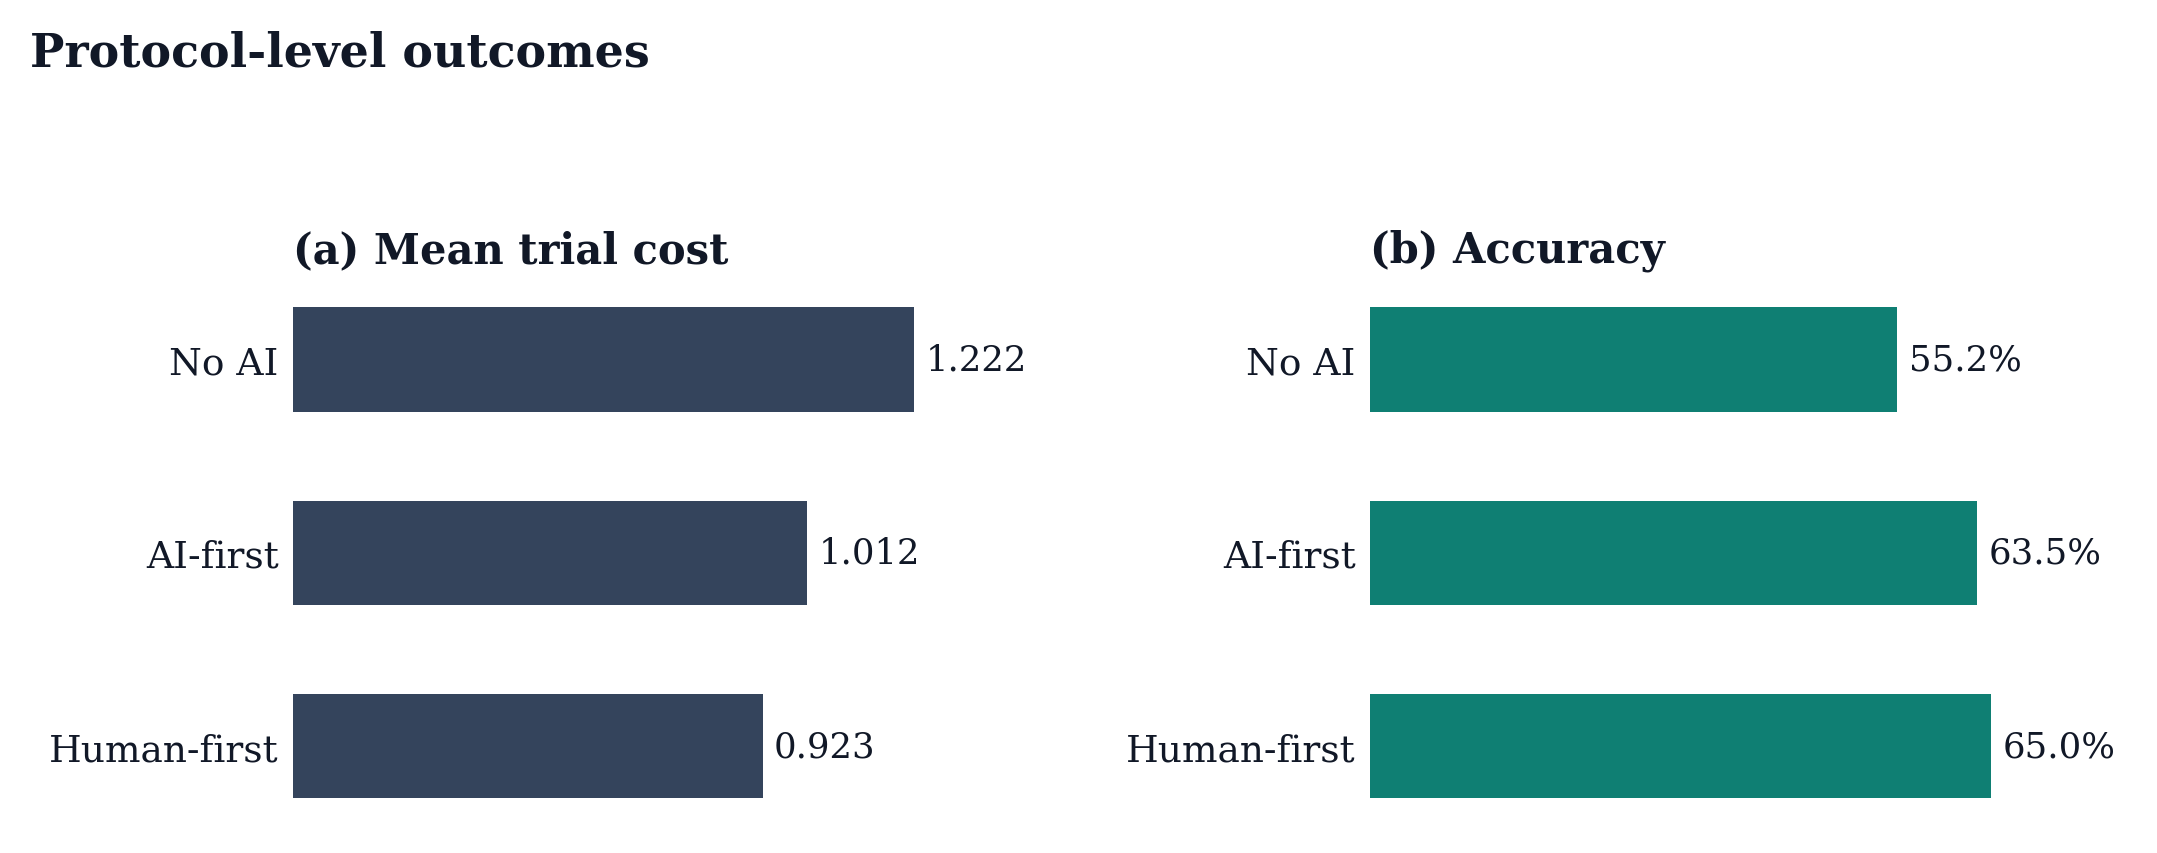

In [13]:
# Figure 1 — cost and accuracy by protocol
protocol_order = ["no_ai", "ai_first", "human_first"]
labels = [PROTOCOL_LABELS[p] for p in protocol_order]

cost_means_plot = [pp_cost[p].mean() for p in protocol_order]
acc_means_plot = [pp_acc[p].mean() for p in protocol_order]
ypos = np.arange(len(protocol_order))

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
fig.patch.set_facecolor("white")

panels = [
    {
        "ax": axes[0],
        "values": cost_means_plot,
        "color": COST_COLOR,
        "title": "(a) Mean trial cost",
        "fmt": "{:.3f}",
        "xlim": (0.0, max(cost_means_plot) * 1.22),
    },
    {
        "ax": axes[1],
        "values": acc_means_plot,
        "color": ACCURACY_COLOR,
        "title": "(b) Accuracy",
        "fmt": "{:.1%}",
        "xlim": (0.0, min(1.0, max(acc_means_plot) * 1.22)),
    },
]

for panel in panels:
    ax = panel["ax"]
    values = panel["values"]
    xmin, xmax = panel["xlim"]

    bars = ax.barh(
        ypos,
        values,
        color=panel["color"],
        height=0.54,
        edgecolor="none",
    )

    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9, color=TEXT_COLOR)
    ax.invert_yaxis()

    ax.set_xlim(xmin, xmax)
    ax.set_title(
        panel["title"],
        loc="left",
        fontsize=10,
        fontweight="bold",
        pad=5,
        color=TEXT_COLOR,
    )

    label_offset = (xmax - xmin) * 0.015
    for bar, value in zip(bars, values):
        ax.text(
            value + label_offset,
            bar.get_y() + bar.get_height() / 2,
            panel["fmt"].format(value),
            ha="left",
            va="center",
            fontsize=8.5,
            color=TEXT_COLOR,
        )

    ax.grid(False)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle(
    "Protocol-level outcomes",
    x=0.01,
    y=1.03,
    ha="left",
    fontsize=11,
    fontweight="bold",
    color=TEXT_COLOR,
)

fig.tight_layout(rect=[0, 0, 1, 0.94], w_pad=2.0)

fig.savefig(
    FIGURES_DIR / "cost_accuracy_by_protocol.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

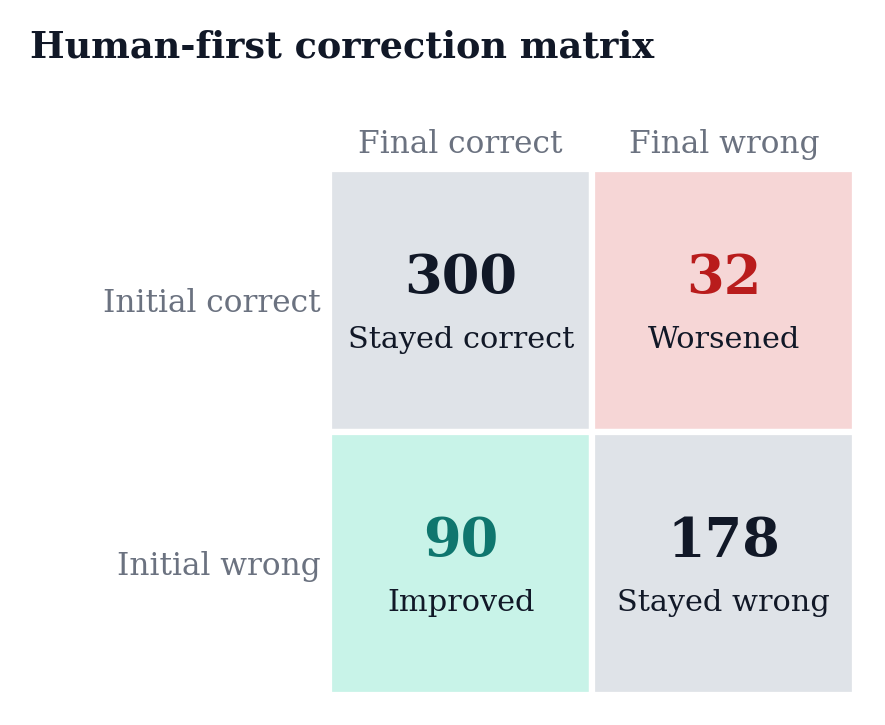

In [14]:
# Figure 2 — human-first correction matrix
matrix = np.array(
    [
        [g_stay_ok, g_worsened],
        [g_improved, g_stay_bad],
    ],
    dtype=float,
)

cell_bg = np.array(
    [
        [CELL_GRAY, CELL_RED],
        [CELL_GREEN, CELL_GRAY],
    ]
)

cell_fg = np.array(
    [
        [TEXT_COLOR, "#B91C1C"],
        ["#0F766E", TEXT_COLOR],
    ]
)

cell_labels = np.array(
    [
        ["Stayed correct", "Worsened"],
        ["Improved", "Stayed wrong"],
    ]
)

fig, ax = plt.subplots(figsize=(3.35, 2.45))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect("equal")

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_bg[i, j],
                edgecolor="white",
                linewidth=1.5,
                zorder=1,
            )
        )

        x = j + 0.5
        y = 1.5 - i

        ax.text(
            x,
            y + 0.08,
            f"{int(matrix[i, j])}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            color=cell_fg[i, j],
            zorder=2,
        )

        ax.text(
            x,
            y - 0.15,
            cell_labels[i, j],
            ha="center",
            va="center",
            fontsize=7.3,
            color=TEXT_COLOR,
            zorder=2,
        )

ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(
    ["Final correct", "Final wrong"],
    fontsize=7.5,
    color=MUTED_TEXT,
)

ax.set_yticklabels(
    ["Initial correct", "Initial wrong"],
    fontsize=7.5,
    color=MUTED_TEXT,
)

ax.xaxis.tick_top()
ax.tick_params(axis="both", length=0, pad=2)

for spine in ax.spines.values():
    spine.set_visible(False)

# True figure-level left-aligned title
fig.text(
    0.02,
    0.98,
    "Human-first correction matrix",
    ha="left",
    va="top",
    fontsize=8.8,
    fontweight="bold",
    color=TEXT_COLOR,
)

fig.tight_layout(rect=[0.04, 0.02, 1.0, 0.90])

fig.savefig(
    FIGURES_DIR / "human_first_correction_matrix.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.show()

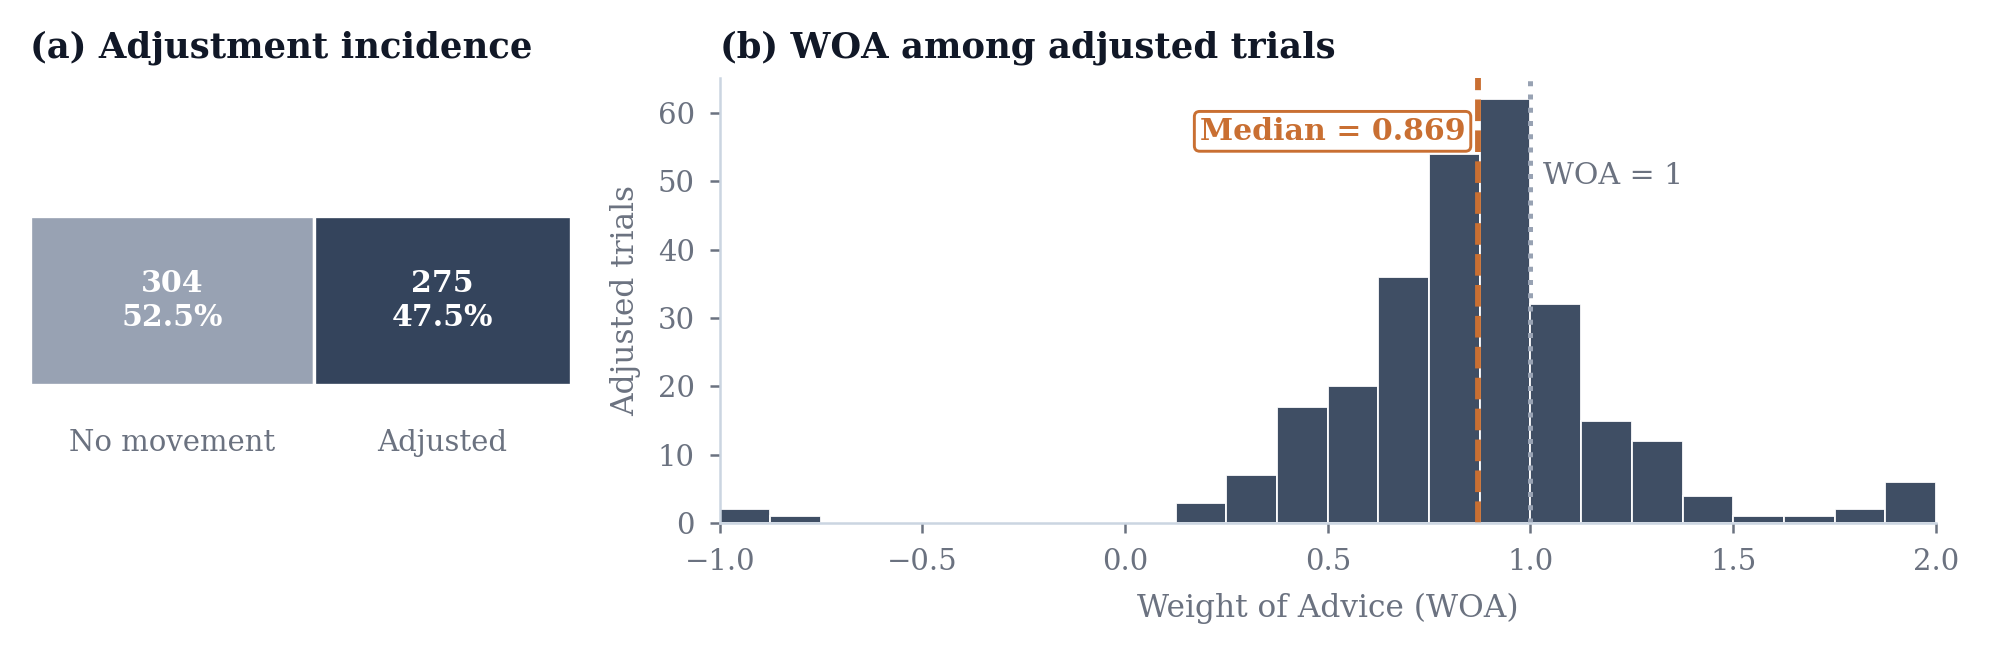

In [15]:
# Figure 3 — WOA distribution
if len(w_all) == 0:
    print("WOA data unavailable — run section 8 first")
else:
    median_adjusted = float(w_adj.median()) if len(w_adj) > 0 else float("nan")
    no_adjust_pct = n_no_adj_woa / n_woa_valid
    adjust_pct = n_adj_woa / n_woa_valid

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(6.7, 2.25),
        gridspec_kw={"width_ratios": [1.0, 2.25]},
    )
    fig.patch.set_facecolor("white")

    ax0, ax1 = axes

    ax0.barh(
        0,
        no_adjust_pct,
        color=WOA_NO_MOVE_COLOR,
        height=0.34,
        edgecolor="white",
        linewidth=0.8,
    )

    ax0.barh(
        0,
        adjust_pct,
        left=no_adjust_pct,
        color=COST_COLOR,
        height=0.34,
        edgecolor="white",
        linewidth=0.8,
    )

    ax0.text(
        no_adjust_pct / 2,
        0,
        f"{n_no_adj_woa}\n{no_adjust_pct:.1%}",
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        color="white",
    )

    ax0.text(
        no_adjust_pct + adjust_pct / 2,
        0,
        f"{n_adj_woa}\n{adjust_pct:.1%}",
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        color="white",
    )

    ax0.text(
        no_adjust_pct / 2,
        -0.26,
        "No movement",
        ha="center",
        va="top",
        fontsize=7,
        color=MUTED_TEXT,
    )

    ax0.text(
        no_adjust_pct + adjust_pct / 2,
        -0.26,
        "Adjusted",
        ha="center",
        va="top",
        fontsize=7,
        color=MUTED_TEXT,
    )

    ax0.set_xlim(0, 1)
    ax0.set_ylim(-0.45, 0.45)
    ax0.set_yticks([])
    ax0.set_xticks([])

    ax0.set_title(
        "(a) Adjustment incidence",
        loc="left",
        fontsize=8.5,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=5,
    )

    ax0.grid(False)

    for spine in ax0.spines.values():
        spine.set_visible(False)

    ax0.tick_params(axis="both", length=0)

    ax1.hist(
        w_adj,
        bins=np.linspace(-1, 2, 25),
        color=COST_COLOR,
        edgecolor="white",
        linewidth=0.45,
        alpha=0.95,
    )

    ax1.axvline(
        median_adjusted,
        color=WOA_MEDIAN_COLOR,
        lw=1.4,
        linestyle="--",
    )

    ax1.axvline(
        1,
        color=WOA_NO_MOVE_COLOR,
        lw=1.2,
        linestyle=":",
    )

    ymax = ax1.get_ylim()[1]

    ax1.text(
        median_adjusted - 0.03,
        ymax * 0.88,
        f"Median = {median_adjusted:.3f}",
        ha="right",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        color=WOA_MEDIAN_COLOR,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor=WOA_MEDIAN_COLOR,
            linewidth=0.7,
        ),
    )

    ax1.text(
        1.03,
        ymax * 0.78,
        "WOA = 1",
        ha="left",
        va="center",
        fontsize=7.2,
        color=MUTED_TEXT,
    )

    ax1.set_xlim(-1, 2)
    ax1.set_xlabel("Weight of Advice (WOA)", fontsize=7.5, color=MUTED_TEXT)
    ax1.set_ylabel("Adjusted trials", fontsize=7.5, color=MUTED_TEXT)

    ax1.set_title(
        "(b) WOA among adjusted trials",
        loc="left",
        fontsize=8.5,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=5,
    )

    ax1.grid(False)

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_color(AXIS_COLOR)
    ax1.spines["bottom"].set_color(AXIS_COLOR)
    ax1.spines["left"].set_linewidth(0.6)
    ax1.spines["bottom"].set_linewidth(0.6)

    ax1.tick_params(
        axis="both",
        colors=MUTED_TEXT,
        labelsize=7,
        width=0.6,
        length=2.5,
    )

    fig.tight_layout(w_pad=1.05)

    fig.savefig(
        FIGURES_DIR / "woa_distribution.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    plt.show()

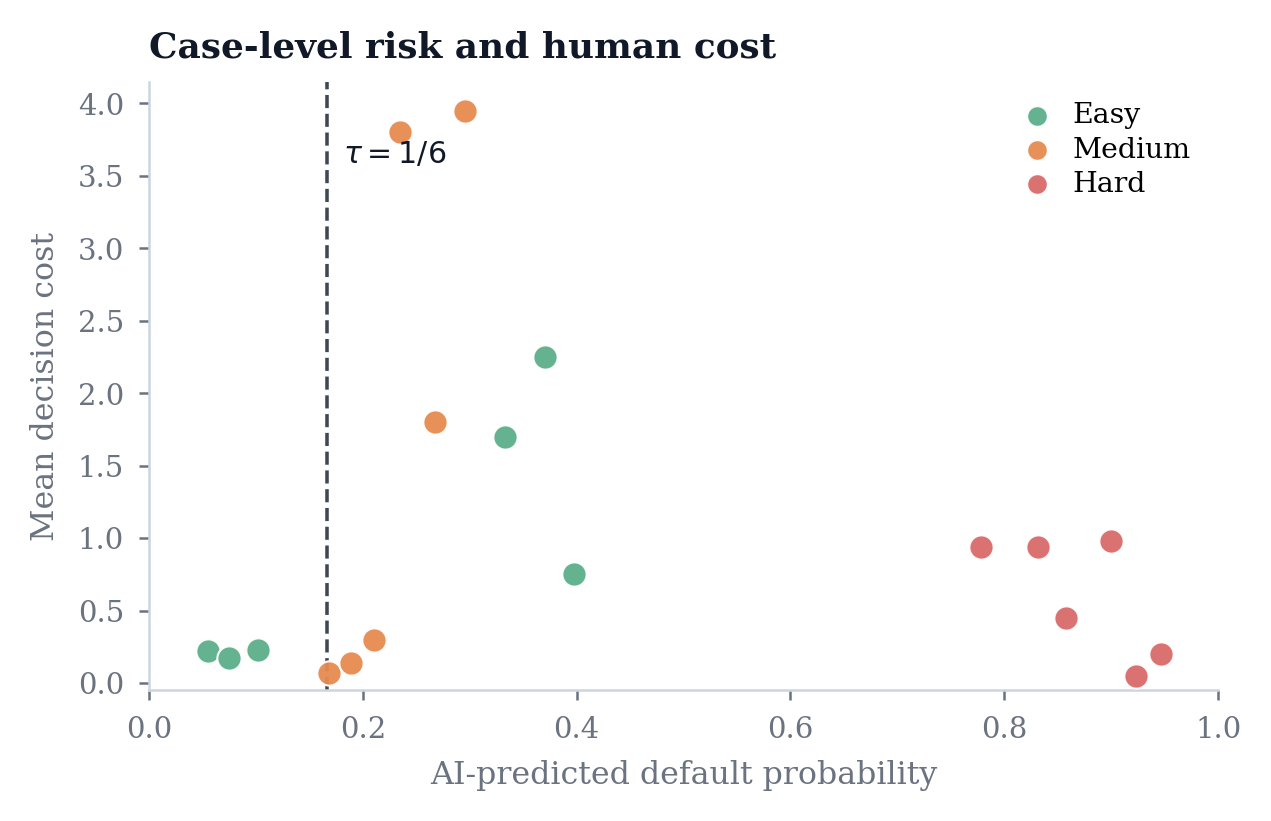

In [16]:
# Figure 4 — case risk vs mean trial cost
if len(case_stats) == 0:
    print("case_stats unavailable — run section 9 first")
else:
    fig, ax = plt.subplots(figsize=(4.15, 2.65))
    fig.patch.set_facecolor("white")

    for tier in TIERS:
        sub = case_stats[case_stats["difficulty_tier"] == tier]

        ax.scatter(
            sub["pred_prob"],
            sub["mean_cost"],
            color=TIER_COLORS[tier],
            label=tier.capitalize(),
            s=34,
            edgecolors="white",
            linewidths=0.5,
            alpha=0.95,
            zorder=3,
        )

    ax.axvline(
        TAU,
        color=TEXT_COLOR,
        linewidth=0.85,
        linestyle="--",
        alpha=0.8,
        zorder=2,
    )

    ax.text(
        TAU + 0.015,
        3.65,
        r"$\tau = 1/6$",
        fontsize=7.2,
        color=TEXT_COLOR,
        ha="left",
        va="center",
    )

    ax.set_xlim(0, 1.0)
    ax.set_ylim(-0.05, 4.15)

    ax.set_xlabel(
        "AI-predicted default probability",
        fontsize=7.6,
        color=MUTED_TEXT,
    )

    ax.set_ylabel(
        "Mean decision cost",
        fontsize=7.6,
        color=MUTED_TEXT,
    )

    ax.set_title(
        "Case-level risk and human cost",
        fontsize=8.6,
        fontweight="bold",
        loc="left",
        color=TEXT_COLOR,
        pad=6,
    )

    ax.legend(
        frameon=False,
        fontsize=6.8,
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        ncol=1,
        handletextpad=0.25,
        labelspacing=0.25,
        borderaxespad=0.0,
        markerscale=0.85,
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_COLOR)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    ax.tick_params(
        axis="both",
        colors=MUTED_TEXT,
        labelsize=7,
        width=0.6,
        length=2.5,
    )

    fig.tight_layout(pad=0.45)

    fig.savefig(
        FIGURES_DIR / "case_risk_cost_scatter.png",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    plt.show()

## Appendix A. Quiz performance

Onboarding quiz descriptives are process checks. They are not part of the primary analysis model.

In [17]:
quiz_scores = quiz_raw.groupby(["participant_id", "attempt"])["is_correct"].sum().reset_index()
quiz_scores.columns = ["participant_id", "attempt", "score"]
attempt1 = quiz_scores[quiz_scores["attempt"] == 1]
attempt2 = quiz_scores[quiz_scores["attempt"] == 2]

n_q = len(attempt1)
print(f"Attempt 1: N={n_q} pass={(attempt1['score'] >= 2).mean():.1%} retry={len(attempt2) / n_q:.1%}")
if len(attempt2):
    print(f"Attempt 2: N={len(attempt2)} pass={(attempt2['score'] >= 2).mean():.1%}")
print("\nScore distribution attempt 1 (max=3):")
print(attempt1["score"].value_counts().sort_index().to_string())

Attempt 1: N=116 pass=80.2% retry=18.1%
Attempt 2: N=21 pass=71.4%

Score distribution attempt 1 (max=3):
score
0     4
1    19
2    11
3    82


## Appendix B. Descriptives by protocol and difficulty

In [18]:
desc = (
    scored_a
    .groupby(["protocol", "difficulty_tier"], observed=True)
    .agg(
        n=("decision_final", "count"),
        accuracy=("correct", "mean"),
        approve_rate=("decision_final", "mean"),
        mean_prob=("prob_estimate_final", "mean"),
    )
    .round(3)
    .reset_index()
    .sort_values(["protocol", "difficulty_tier"])
)
print(desc.to_string(index=False))

   protocol difficulty_tier   n  accuracy  approve_rate  mean_prob
   ai_first            easy 200     0.810         0.590      0.250
   ai_first          medium 200     0.585         0.745      0.209
   ai_first            hard 200     0.510         0.040      0.802
human_first            easy 200     0.820         0.580      0.281
human_first          medium 200     0.625         0.705      0.201
human_first            hard 200     0.505         0.025      0.776
      no_ai            easy 200     0.590         0.490      0.337
      no_ai          medium 200     0.580         0.750      0.214
      no_ai            hard 200     0.485         0.075      0.597


## Appendix C. Participant probability calibration

ECE here describes human final probability estimates, not the AI model. This is descriptive only and should not be overinterpreted because each participant contributes only 18 scored trials.

In [ ]:
def compute_ece(y_true_arr, prob_arr, n_bins=3):
    y_true_arr = np.asarray(y_true_arr)
    prob_arr = np.asarray(prob_arr)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true_arr)
    if n == 0:
        return np.nan
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (prob_arr >= bins[i]) & (prob_arr < bins[i + 1])
        else:
            mask = (prob_arr >= bins[i]) & (prob_arr <= bins[i + 1])
        if not mask.any():
            continue
        ece += (mask.sum() / n) * abs(float(y_true_arr[mask].mean()) - float(prob_arr[mask].mean()))
    return ece

rows = []
for pid in completed_ids:
    sub = scored_a[scored_a["participant_id"] == pid]
    if len(sub) < 2:
        continue
    rows.append({
        "participant_id": pid,
        "global_ece": compute_ece(
            sub["y_true"].values.astype(float),
            sub["prob_estimate_final"].values.astype(float),
        ),
    })

ece_df = pd.DataFrame(rows)
if not ece_df.empty:
    vals = ece_df["global_ece"].dropna()
    print(f"Global ECE (3-bin): mean={vals.mean():.4f} SD={vals.std():.4f} median={vals.median():.4f}")

Global ECE (3-bin): mean=0.2714 SD=0.0611 median=0.2692


## Appendix D. Normative deviation by difficulty

This diagnostic compares final decisions with the cost-sensitive threshold-implied action. It is descriptive and helps explain where decision errors were concentrated.

In [20]:
scored_a["optimal_dec"] = (scored_a["pred_prob"] < TAU).astype(int)
scored_a["deviates"] = (scored_a["decision_final"] != scored_a["optimal_dec"]).astype(int)

print("Normative deviation by difficulty:")
print(
    scored_a
    .groupby("difficulty_tier", observed=True)
    .agg(deviation_rate=("deviates", "mean"), n=("deviates", "count"))
    .round(4)
    .reindex(TIERS)
    .to_string()
)

print("\nAccuracy by difficulty × protocol:")
print(
    scored_a
    .groupby(["difficulty_tier", "protocol"], observed=True)["correct"]
    .mean()
    .unstack("protocol")
    .round(3)
    .reindex(TIERS)
    .to_string()
)

Normative deviation by difficulty:
                 deviation_rate    n
difficulty_tier                     
easy                     0.2600  600
medium                   0.7333  600
hard                     0.0467  600

Accuracy by difficulty × protocol:
protocol         ai_first  human_first  no_ai
difficulty_tier                              
easy                0.810        0.820  0.590
medium              0.585        0.625  0.580
hard                0.510        0.505  0.485


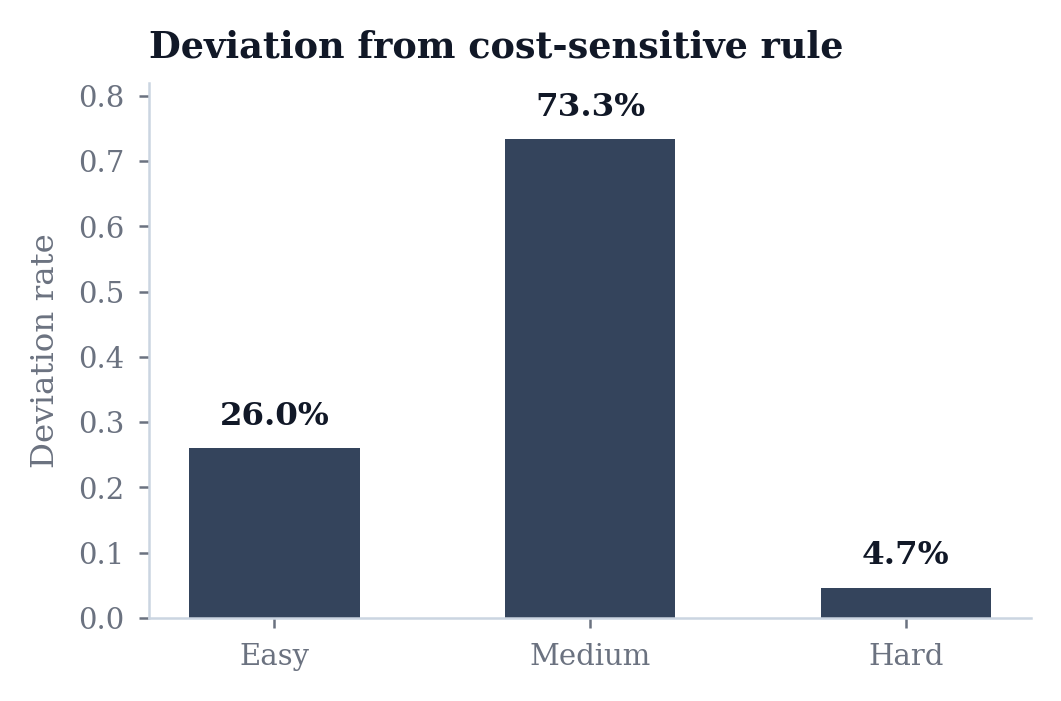

In [21]:
# Figure 5 — normative deviation by difficulty
dev_by_tier = (
    scored_a
    .groupby("difficulty_tier", observed=True)
    .agg(deviation_rate=("deviates", "mean"), n=("deviates", "count"))
    .reindex(TIERS)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(3.45, 2.25))
fig.patch.set_facecolor("white")

x = np.arange(len(dev_by_tier))
values = dev_by_tier["deviation_rate"].values

bars = ax.bar(
    x,
    values,
    color=COST_COLOR,
    width=0.54,
    edgecolor="none",
)

ax.set_xticks(x)
ax.set_xticklabels(
    [str(t).capitalize() for t in dev_by_tier["difficulty_tier"]],
    fontsize=8,
    color=TEXT_COLOR,
)

ax.set_ylim(0, 0.82)
ax.set_ylabel("Deviation rate", fontsize=7.8, color=MUTED_TEXT)
ax.set_title(
    "Deviation from cost-sensitive rule",
    loc="left",
    fontsize=8.8,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=6,
)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=7.8,
        color=TEXT_COLOR,
        fontweight="bold",
    )

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(AXIS_COLOR)
ax.spines["bottom"].set_color(AXIS_COLOR)
ax.spines["left"].set_linewidth(0.6)
ax.spines["bottom"].set_linewidth(0.6)
ax.tick_params(
    axis="both",
    colors=MUTED_TEXT,
    labelsize=7,
    width=0.6,
    length=2.5,
)

fig.tight_layout(pad=0.45)
fig.savefig(
    FIGURES_DIR / "normative_deviation_by_difficulty.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
)
plt.show()

## Appendix E. Individual differences in AI benefit

Participant-level AI benefit is exploratory. It is useful for sanity-checking heterogeneity but is not a primary inferential endpoint.

In [22]:
acc_wide = pp_acc.copy()
acc_wide.columns = [f"acc_{c}" for c in acc_wide.columns]
cost_wide = pp_cost.copy()
cost_wide.columns = [f"cost_{c}" for c in cost_wide.columns]
benefit = acc_wide.join(cost_wide, how="outer")

if {"acc_ai_first", "acc_human_first", "acc_no_ai"}.issubset(benefit.columns):
    benefit["ai_benefit_acc"] = benefit[["acc_ai_first", "acc_human_first"]].mean(axis=1) - benefit["acc_no_ai"]

if {"cost_ai_first", "cost_human_first", "cost_no_ai"}.issubset(benefit.columns):
    benefit["ai_benefit_cost"] = benefit["cost_no_ai"] - benefit[["cost_ai_first", "cost_human_first"]].mean(axis=1)

quiz_attempt1 = quiz_raw[quiz_raw["attempt"] == 1].groupby("participant_id")["is_correct"].sum()
benefit["quiz_score"] = quiz_attempt1

for col in ["ai_benefit_acc", "ai_benefit_cost"]:
    if col in benefit:
        vals = benefit[col].dropna()
        print(f"{col}: mean={vals.mean():.4f} SD={vals.std():.4f} median={vals.median():.4f}")

ai_benefit_acc: mean=0.0908 SD=0.1914 median=0.0833
ai_benefit_cost: mean=0.2542 SD=0.7543 median=0.3333


## Appendix F. Implicit decision-threshold estimation

This exploratory check estimates an approximate individual threshold from no-AI decisions only. Estimates are noisy because each participant contributes only six no-AI trials.

In [23]:
from sklearn.linear_model import LogisticRegression

threshold_rows = []
for pid in sorted(completed_ids):
    sub = scored_a[
        (scored_a["participant_id"] == pid) &
        (scored_a["protocol"] == "no_ai")
    ].dropna(subset=["prob_estimate_final", "decision_final"])

    X = sub["prob_estimate_final"].values.reshape(-1, 1)
    y = sub["decision_final"].values.astype(int)

    if len(sub) < 4 or y.std() == 0 or X.std() == 0:
        threshold_rows.append({"participant_id": pid, "implicit_threshold": np.nan, "reason": "insufficient"})
        continue

    try:
        clf = LogisticRegression(max_iter=1000, solver="lbfgs")
        clf.fit(X, y)
        coef = clf.coef_[0][0]
        intercept = clf.intercept_[0]
        if abs(coef) > 50 or coef == 0:
            threshold_rows.append({"participant_id": pid, "implicit_threshold": np.nan, "reason": "extreme"})
        else:
            threshold_rows.append({
                "participant_id": pid,
                "implicit_threshold": float(np.clip(-intercept / coef, 0, 1)),
                "reason": "ok",
            })
    except Exception as exc:
        threshold_rows.append({"participant_id": pid, "implicit_threshold": np.nan, "reason": str(exc)})

threshold_df = pd.DataFrame(threshold_rows)
ok_thresholds = threshold_df[threshold_df["reason"] == "ok"]["implicit_threshold"]
print(f"Valid estimates: {len(ok_thresholds)}/{len(threshold_df)}")
if len(ok_thresholds) > 0:
    print(
        f"Mean={ok_thresholds.mean():.3f} SD={ok_thresholds.std():.3f} "
        f"Median={ok_thresholds.median():.3f} (benchmark TAU={TAU:.4f})"
    )

Valid estimates: 96/100
Mean=0.355 SD=0.383 Median=0.299 (benchmark TAU=0.1667)


## Appendix G. Participant context

In [24]:
reflect_cols = [c for c in ["id", "trust_rating", "self_reported_reliance", "age_range", "education"] if c in participants_a.columns]
reflect = participants_a[reflect_cols].copy().rename(columns={"id": "participant_id"})

print(f"\nCompleted sample (N={len(reflect)}):")
for col in ["age_range", "education"]:
    if col in reflect.columns:
        print(reflect[col].value_counts(dropna=True).to_string())

print("\nNote: sample is predominantly young/student participants; external validity to professional loan officers is limited.")


Completed sample (N=100):
age_range
18-24    78
25-34    14
35-44     6
education
Bachelor's (in progress)    56
Master's or higher          28
Bachelor's (completed)       9
High school                  5

Note: sample is predominantly young/student participants; external validity to professional loan officers is limited.


## Final notebook status

Expected core results after a successful run:

- Completed participants: `N = 100`
- Scored trials: `1,800`
- Cost means: `1.2217`, `1.0117`, `0.9233`
- Accuracy means: `0.5517`, `0.6350`, `0.6500`
- Human-first correction matrix: `300`, `32`, `90`, `178`
- WOA-valid trials: `579`
- No-adjustment WOA-valid trials: `304 / 579 = 52.5%`
- Median WOA among adjusted trials: `0.869`